In [1]:
%load_ext autoreload
%autoreload 2

# Visualise sequence mutations for Thesis

Dataset overview:

1. Dataset `2024_11_27_145142` was resimulated with different starting copy numbers in the following: 
Datasets:
- Original: `2024_11_27_145142`
- Starting copies = 100, dt0 = 0.0001: `2026_01_12__18_50_13`
- Starting copies = 200, dt0 = 0.0001: `2026_01_14__22_38_47`
- Starting copies = 100, dt0 = 0.01: `2026_01_15__15_43_12`

2. Dataset `2024_11_21_160955` was resimulated as dataset `2025_02_11__13_56_51`. 

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from common import set_theme, add_sample_names
from synbio_morpher.utils.results.analytics.timeseries import calculate_adaptation

PALETTE = 'viridis'


In [3]:
'data/raw/summarise_simulation/2024_11_21_160955/tabulated_mutation_info.csv'
'data/simulate_circuits/2026_01_12__18_50_13/config.json'
'data/simulate_circuits/2026_01_12__18_50_13/analytics.json'

'data/simulate_circuits/2026_01_12__18_50_13/analytics.json'

In [5]:
fn_og = '../data/raw/summarise_simulation/2024_11_27_145142/tabulated_mutation_info.csv'
fn_resim = '../notebooks/data/simulate_circuits/2026_01_12__18_50_13/analytics.json'
data = pd.read_csv(fn_og)
df_resim = pd.read_json(fn_resim).drop(columns='RMSE')
df_resim = df_resim.explode(df_resim.columns.to_list()).reset_index(drop=True)
cols_resim = list(df_resim.columns)

In [ ]:
names_species_input = data['sample_name'].unique()
n_species_input = len(names_species_input)
n_species_total = int(len(df_resim) / len(data) * n_species_input)

df_resim = add_sample_names(df_resim, names_species_input, n_species_input, n_species_total)
data[cols_resim] = df_resim.query('sample_name in ["RNA_0", "RNA_1", "RNA_2"]')[cols_resim].values.astype(np.float32)
del df_resim

data.rename(columns={'mutation_num': 'N mutations'}, inplace=True)
data['Log sensitivity'] = np.log10(data['sensitivity'])
data['Log precision'] = np.log10(data['precision'])
data['adaptation'] = calculate_adaptation(np.array(data['sensitivity']), np.array(data['precision']), alpha=2)

In [14]:
for k in ['Log sensitivity', 'Log precision', 'adaptation']:
    # data[f'{k} diffs'] = data.groupby(['circuit_name', 'sample_name'])[k].apply(lambda x: x - x.iloc[0]).reset_index()[k]
    data[f'{k} diffs'] = data.groupby(['circuit_name', 'sample_name'])[k].apply(lambda x: x - x.iloc[0]).reset_index().sort_values('level_2').reset_index()[k]
    data[f'{k} ratio'] = data.groupby(['circuit_name', 'sample_name'])[k].apply(lambda x: x/x.iloc[0]).reset_index().sort_values('level_2').reset_index()[k]

# Loss of adaptable circuits

In [29]:
filt_adapt = (data['Log sensitivity'] > -1) & (data['Log precision'] > 0.5)
filt_m = data['N mutations'] > 0

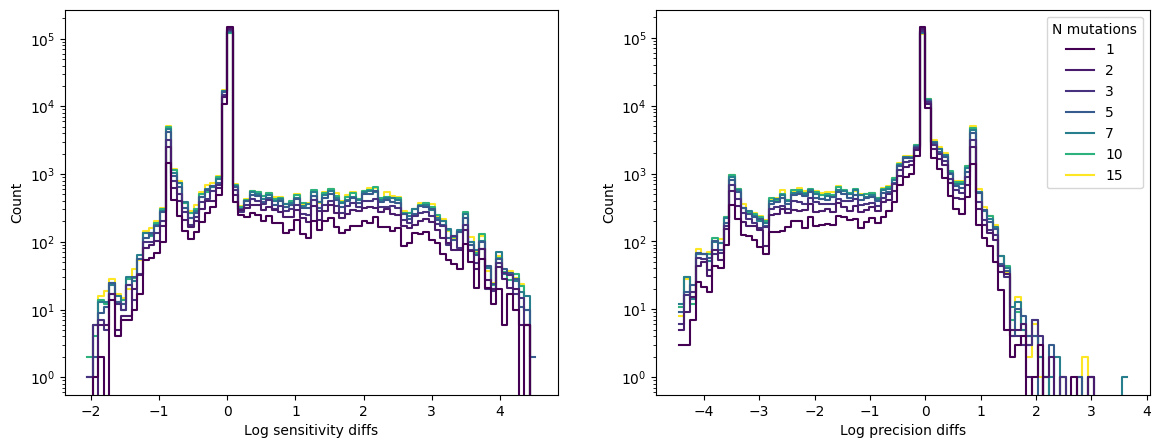

In [30]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data[filt_adapt & filt_m], x=f'Log sensitivity diffs', hue='N mutations',
            palette=PALETTE, bins=80, fill=False, element='step', ax=axs[0], legend=False)
axs[0].set_yscale('log')
sns.histplot(data[filt_adapt & filt_m], x=f'Log precision diffs', hue='N mutations',
            palette=PALETTE, bins=80, fill=False, element='step', ax=axs[1], legend=True)
axs[1].set_yscale('log')